# Importing

In [1]:
import os
import sys
import numpy as np
import csv  # save file
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
# ------------ SETS PATH ------------ #
currentdir = os.getcwd()
parentdir = os.path.dirname(currentdir)
makePlotsDir = parentdir + '\\make-plots'

# ------------ FILES CURRENTDIR ------------ #
sys.path.insert(0, currentdir)

# ------------ FILES makePlotsDir ------------ #
sys.path.insert(0, makePlotsDir)
from plotsWholeComparison import plotFullComparison, plotFullComparison_vol2
from plotEvolutionRhoISO import plotEvolutionRhoISO

# ------------ FILES PARENTDIR ------------ #
sys.path.insert(0, parentdir)
from NFW_class import NFW_profile, r1
from Isothermal_paper_2206 import findTwoDeltaMinimum
import Config as cfg
import AuxiliaryFunctions as aux
from ISO_and_NFW import ISO_and_NFW

# SETS OF SIMULATION: USER SETS!

In [2]:
sigma_m = 1.0  # [cm^2/g] annihilation cross-section
sigma_m_SI = sigma_m * 10**(-4) * 10**3  # [m^2/kg]
M_vir = 5*10**10.00  # [M_sun] Viral mass
const_c = aux.DMc_gravo(M_vir, 0, cfg.const_h)  # [dimensionless] concentration of DM
# const_c = 15.0  # [dimensionless] concentration of DM
tage = 60.0  # [Gyr]

r = np.logspace(-3, 2.0, 300)

# CREATING NFW CLASS

In [3]:
NFW_profile = NFW_profile(M_vir, const_c)
r_s = NFW_profile.r_s
rounded_r_s = cfg.rounded_number(r_s, 3)

rho_s = NFW_profile.rho_s
rounded_rho_s = cfg.rounded_number(rho_s, 3)
print(f"rho_s = {rounded_rho_s} [M_solar / kpc^3], r_s = {'{:.3f}'.format(r_s)} [kpc]")

r_1 = r1(NFW_profile, sigmamx=sigma_m, tage=tage)
print("r_1:", r_1)

rho_s = 7590000.0 [M_solar / kpc^3], r_s = 6.904 [kpc]
r_1: 10.252470992208782


In [8]:
print("NFW(r=0.001)", NFW_profile.rho(0.001), "[M_sun/kpc^3]")
print("NFW(r=0.01)", NFW_profile.rho(0.01), "[M_sun/kpc^3]")
print("NFW(r=0.001)/NFW(r=0.01)", NFW_profile.rho(0.001) / NFW_profile.rho(0.01), "[M_sun/kpc^3]")
print("stable high dense solution from", aux.cal_time_tilda(115, rho_s, r_s, sigma_m), "[dimesionless]")
print("stable high dense solution from", aux.convert_time_tilda(58.81398403499673, rho_s, r_s, sigma_m), "[Gyr]")

NFW(r=0.001) 52400100785.73821 [M_sun/kpc^3]
NFW(r=0.01) 5226377348.575618 [M_sun/kpc^3]
NFW(r=0.001)/NFW(r=0.01) 10.02608447321914 [M_sun/kpc^3]
stable high dense solution from 58.81398403499673 [dimesionless]
stable high dense solution from 115.0 [Gyr]


In [4]:
# important points
print("stable high dense solution from", aux.cal_time_tilda(90, rho_s, r_s, sigma_m), "[dimesionless]")
print("stable high dense solution from", aux.cal_time_tilda(100, rho_s, r_s, sigma_m), "[dimesionless]")
print("stable high dense solution from", aux.cal_time_tilda(110, rho_s, r_s, sigma_m), "[dimesionless]")
print("stable high dense solution from", aux.cal_time_tilda(115, rho_s, r_s, sigma_m), "[dimesionless]")
print("stable high dense solution from", aux.cal_time_tilda(120, rho_s, r_s, sigma_m), "[dimesionless]")
print()
# WHEN WE HAVE STABLE HIGH DENSE SOLUTION
r_1_stableHiDen = r1(NFW_profile, sigmamx=sigma_m, tage=aux.convert_time_tilda(61.37111377564876 , rho_s, r_s, sigma_m))
print("stable High Dense solution we can obtain after:" + r"$r_1$" + 
      f" > {'{:.3f}'.format(r_1_stableHiDen)} [kpc]")
print("stable High Dense solution we can obtain after:" + r" $r_1$" + 
      f" > {'{:.3f}'.format(r_1_stableHiDen / r_s)} [dimensionless]")

stable high dense solution from 46.02833533173657 [dimesionless]
stable high dense solution from 51.14259481304063 [dimesionless]
stable high dense solution from 56.2568542943447 [dimesionless]
stable high dense solution from 58.81398403499673 [dimesionless]
stable high dense solution from 61.37111377564876 [dimesionless]

stable High Dense solution we can obtain after:$r_1$ > 13.747 [kpc]
stable High Dense solution we can obtain after: $r_1$ > 1.991 [dimensionless]


In [10]:
r_1_coll = 0
time = 0.0 # [Gyr]
while r_1_coll < 1.0:
    r_1_coll = r1(NFW_profile, sigmamx=sigma_m, tage=time) / r_s
    time = time + 0.1
    
print("r_1_coll:", r_1_coll)
print("time:", time, "[Gyr]")

r_1_coll: 1.0003695458555897
time: 25.700000000000095 [Gyr]


# ISOTHERMAL

In [4]:
SIDM_LoDens, SIDM_HiDens = findTwoDeltaMinimum(r_1, NFW_profile)  # by default r_low=-3.

In [5]:
# --- LOW DENSE
rho0 = SIDM_LoDens[0]  # [M_sun/kpc^3]
nu0 = SIDM_LoDens[1]  # [kpc/Gyr]

IsoLow_data = dict()
IsoLow_data['r'] = np.array(SIDM_LoDens[4])  # [kpc]
IsoLow_data['rho'] = np.array(SIDM_LoDens[2])  # [M_sun/kpc^3]
IsoLow_data['mass'] = np.array(SIDM_LoDens[5])  # [M_sun]

print(f'central DM density: {rho0} [M_sun/kpc^3]')
print(f'central DM velocity dispersion: {nu0} [kpc/Gyr]')

# --- HIGH DENSE
IsoHi_data = dict()
IsoHi_data['r'] = np.array(SIDM_HiDens[4])  # [kpc]
IsoHi_data['rho'] = np.array(SIDM_HiDens[2])  # [M_sun/kpc^3]
IsoHi_data['mass'] = np.array(SIDM_HiDens[5])  # [M_sun]

# --- ISO AND NFW
parameters_map = dict()
parameters_map['Mvir'] = M_vir
parameters_map['c_const'] = const_c
parameters_map['r1'] = r_1  # [kpc]
parameters_map['t'] = tage  # [Gyr]


# --- ISO LOW AND NFW
IsoLow_class = ISO_and_NFW([IsoLow_data["r"], IsoLow_data["rho"], IsoLow_data["mass"]], parameters_map)

IsoLowAndNFW_data = dict()
IsoLowAndNFW_data["r"] = np.array([])
IsoLowAndNFW_data["rho"] = np.array([])
IsoLowAndNFW_data["mass"] = np.array([])
IsoLowAndNFW_data["velDis"] = np.array([])


IsoLowAndNFW_data["r"] = np.append(IsoLowAndNFW_data["r"], r)  # radius [kpc]
IsoLowAndNFW_data["rho"] = np.append(IsoLowAndNFW_data["rho"],
                                     IsoLow_class.rho_return(r))  # density [M_sun/kpc^3]
IsoLowAndNFW_data["mass"] = np.append(IsoLowAndNFW_data["mass"],
                                      IsoLow_class.M_enclosed_return(r))  # enclosed mass [M_sun]
IsoLowAndNFW_data["velDis"] = np.append(IsoLowAndNFW_data["velDis"],
                                        IsoLow_class.velDis(r))  # nu in [kpc/Gyr]

# --- ISO HIGH AND NFW
IsoHi_class = ISO_and_NFW([IsoHi_data["r"], IsoHi_data["rho"], IsoHi_data["mass"]], parameters_map)

IsoHiAndNFW_data = dict()
IsoHiAndNFW_data["r"] = np.array([])
IsoHiAndNFW_data["rho"] = np.array([])
IsoHiAndNFW_data["mass"] = np.array([])
IsoHiAndNFW_data["velDis"] = np.array([])

IsoHiAndNFW_data["r"] = np.append(IsoHiAndNFW_data["r"], r)  # radius [kpc]
IsoHiAndNFW_data["rho"] = np.append(IsoHiAndNFW_data["rho"],
                                    IsoHi_class.rho_return(r))  # density [M_sun/kpc^3]
IsoHiAndNFW_data["mass"] = np.append(IsoHiAndNFW_data["mass"],
                                     IsoHi_class.M_enclosed_return(r))  # enclosed mass [M_sun]
IsoHiAndNFW_data["velDis"] = np.append(IsoHiAndNFW_data["velDis"],
                                       IsoHi_class.velDis(r))  # nu in [kpc/Gyr]

central DM density: 13813240.147525748 [M_sun/kpc^3]
central DM velocity dispersion: 41.3686572942605 [kpc/Gyr]


C:\Users\Krzysztof\Documents\GitHub\DarkMatterProfiles\R-procedure\NFW-Isothermal-paper-2206\ISO_and_NFW.py:431: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  I = quad(f, r, self.r1, epsabs=1.e-7, epsrel=1.e-6, limit=10000)[0]


# NFW DATA

In [6]:
NFW_data = dict()
NFW_data['r'] = r  # [kpc]
NFW_data['rho'] = NFW_profile.rho(r)  # [M_sun/kpc^3]
NFW_data['mass'] = NFW_profile.Mass(r)  # [M_sun]
NFW_data['velDis'] = NFW_profile.sigma_accurate(r)  # [kpc/Gyr]

# Plot: ENCLOSED MASS

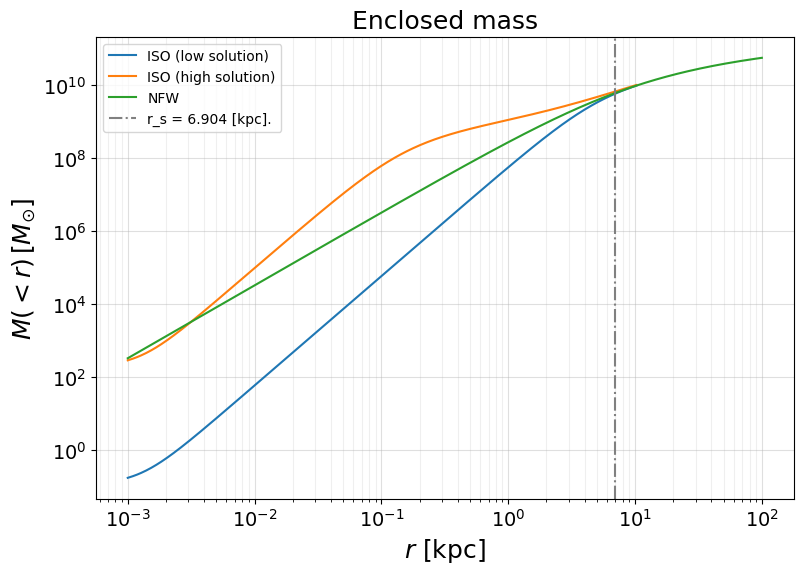

In [7]:
fig, ax = plt.subplots(figsize=(9.0, 6.0))
# log scale
ax.set_xscale('log')
ax.set_yscale('log')
plt.ylabel(r"$M(<r) \, [M_{\odot}]$", fontsize=18)
plt.xlabel(r"$r$ [kpc]", fontsize=18)
plt.title("Enclosed mass", fontsize=18)
ax.tick_params(labelsize=14)
# data
ax.plot(IsoLow_data['r'], IsoLow_data['mass'], label="ISO (low solution)")
ax.plot(IsoHi_data['r'], IsoHi_data['mass'], label="ISO (high solution)")
ax.plot(NFW_data['r'], NFW_data['mass'], label="NFW")

# grid
ax.grid(which='minor', alpha=0.2)
ax.grid(which='major', alpha=0.4)
# for refined control of log-scale tick marks
locmaj = mticker.LogLocator(base=10, numticks=12)
locmin = mticker.LogLocator(base=10.0,
                            subs=(0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9),
                            numticks=12)
ax.xaxis.set_major_locator(locmaj)
ax.xaxis.set_minor_locator(locmin)
ax.xaxis.set_minor_formatter(mticker.NullFormatter())

# lines
plt.axvline(x=r_s, color='grey', linestyle='dashdot',
            label=f'r_s = {"{:.3f}".format(r_s)} [kpc].')

ax.legend()
plt.show()

# Plot: DENSITY

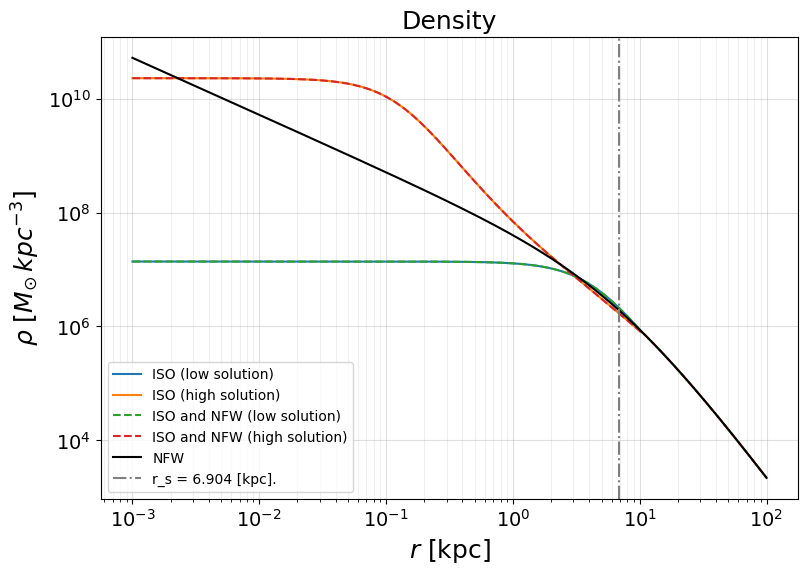

In [8]:
fig, ax = plt.subplots(figsize=(9.0, 6.0))
# log scale
ax.set_xscale('log')
ax.set_yscale('log')
plt.ylabel(r"$\rho \, \, [M_{\odot} \, kpc^{-3}]$", fontsize=18)
plt.xlabel(r"$r$ [kpc]", fontsize=18)
plt.title("Density", fontsize=18)
ax.tick_params(labelsize=14)
# --- DATA
# --- ISO
ax.plot(IsoLow_data['r'], IsoLow_data['rho'], label="ISO (low solution)")
ax.plot(IsoHi_data['r'], IsoHi_data['rho'], label="ISO (high solution)")
# --- ISO AND NFW
ax.plot(IsoLowAndNFW_data['r'], IsoLowAndNFW_data['rho'], "--", label="ISO and NFW (low solution)")
ax.plot(IsoHiAndNFW_data['r'], IsoHiAndNFW_data['rho'], "--", label="ISO and NFW (high solution)")
# --- NFW
ax.plot(NFW_data['r'], NFW_data['rho'], "black",label="NFW")

# grid
ax.grid(which='minor', alpha=0.2)
ax.grid(which='major', alpha=0.4)
# for refined control of log-scale tick marks
locmaj = mticker.LogLocator(base=10, numticks=12)
locmin = mticker.LogLocator(base=10.0,
                            subs=(0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9),
                            numticks=12)
ax.xaxis.set_major_locator(locmaj)
ax.xaxis.set_minor_locator(locmin)
ax.xaxis.set_minor_formatter(mticker.NullFormatter())

# lines
plt.axvline(x=r_s, color='grey', linestyle='dashdot',
            label=f'r_s = {"{:.3f}".format(r_s)} [kpc].')

ax.legend()
plt.show()

# Plot: VELOCITY DISPERSION

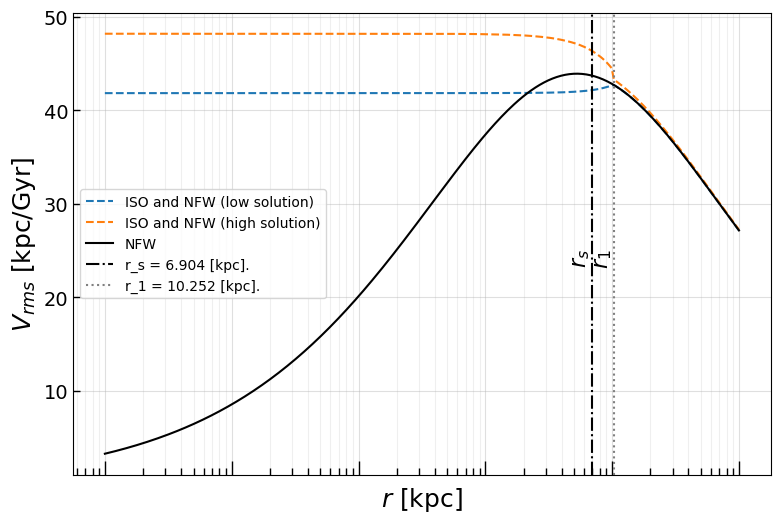

In [9]:
fig, ax = plt.subplots(figsize=(9.0, 6.0))
# log scale
ax.set_xscale('log')
# describe
plt.ylabel(r"$V_{rms}$ [kpc/Gyr]", fontsize=18)
plt.xlabel(r"$r$ [kpc]", fontsize=18)

# --- DATA
# --- ISO AND NFW
ax.plot(IsoLowAndNFW_data['r'], IsoLowAndNFW_data['velDis'], "--", label="ISO and NFW (low solution)")
ax.plot(IsoHiAndNFW_data['r'], IsoHiAndNFW_data['velDis'], "--", label="ISO and NFW (high solution)")
# --- NFW
ax.plot(NFW_data['r'], NFW_data['velDis'], "black",label="NFW")

# grid
ax.tick_params(labelsize=14)
ax.grid(which='minor', alpha=0.2)
ax.grid(which='major', alpha=0.4)
# for refined control of log-scale tick marks
locmaj = mticker.LogLocator(base=10, numticks=12)
locmin = mticker.LogLocator(base=10.0,
                            subs=(0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9),
                            numticks=12)
ax.xaxis.set_major_locator(locmaj)
ax.xaxis.set_minor_locator(locmin)
ax.xaxis.set_minor_formatter(mticker.NullFormatter())
# tick length
ax.tick_params('x', direction='in', top=0, right=0, length=10,
               width=1, which='major', zorder=301)
ax.tick_params('x', direction='in', top=0, right=0, length=5,
               width=1, which='minor', zorder=301)
ax.tick_params('y', direction='in', top=0, right=0, length=5,
               width=1, which='both', zorder=301)

# lines
plt.axvline(x=r_s, color='black', linestyle='dashdot',label=f'r_s = {"{:.3f}".format(r_s)} [kpc].')
plt.axvline(x=r_1, color='grey', linestyle=':',label=f'r_1 = {"{:.3f}".format(r_1)} [kpc].')
# annotation to lines
ax.text(r_s, 0.5 * ax.get_ylim()[1], r'$r_{s}$', color='k', fontsize=16,
        ha='right', va='top', transform=ax.transData, rotation=90)
ax.text(r_1, 0.5 * ax.get_ylim()[1], r'$r_{1}$', color='k', fontsize=16,
        ha='right', va='top', transform=ax.transData, rotation=90)

ax.legend()
plt.show()